## Kunskapskontroll 1
**Student:** Joakim Reuterborg

### Fråga 1:
Finns det en korrelation mellan antalet storkar och antalet födda barn?

**Svar:**<br>
Man kan se en viss korrelation men ingen kausalitet eftersom storkar bevisligen inte transporterar människobarn

### Fråga 2:
Korrelation påvisar sambandet mellan förklarande variabel och responsvariabel i ett n-dimensionellt diagram, oftast spridningsdiagram.

Kort sagt - ser man massa prickar kan man ibland avgöra att dessa har ett samband till varandra - men inte nödvändigtvis vad orsaken till detta är. X-axeln (den vågräta, förklarande variabeln) o Y-axeln (den lodräta, responsvariabeln) representerar de olika värdena på respektive variabel

Lutningen och riktningen på sambandet är väsentliga i de fall man kan se en korrelation, vars tydlighet kan beräknas. Lutningen och riktning påvisar positiva, negativa, svaga och starka korrelationer.

#### Rad 1
I bilderna kan vi på den översta raden från vänster först se en tydlig **positiv korrelation**: respektive variabel ökar i värde och linjen pekar till synes 45° uppåt/höger

**Svag positiv korrelation** - till - **ingen korrelation** - till - **svag negativ korrelation** påvisr de fem mittersta spridningsdiagrammen

**Stark negativ korrelation** påvisar det sista spridningsdiagrammet

#### Rad 2
Här är samtliga spridningsdiagrammen så tydliga i sin riktning att det nästan är osannolikt bra data.

#### Rad 3
Dessa spridningsdiagram, även om formerna är intressanta o underhållande, påvisar ingen korrelation men man kanske skulle kunna utröna en kausalitet om man visste vad respektive variabel stod för

### Fråga 3
Jag håller med Fredrik o hela hans spelklubb.
Däremot gällande att medelvärdet skulle vara ett bättre mått än medianvärdet är inget man kan bekräfta eller dementer, eftersom det handlar om vad man använder det till.

### Fråga 4
Cirkeldiagram är fenomenala för att jämföra hur olika diskreta värden återfinns i olika utsträckning. Grafiken är en rund ost / tårta där triangelformade tårtbitar utgör en förevisad procentuell del av den totala omkretsen 

### Fråga 5
Spotify skulle kunna använda linediagram för att skapa statistik över up-n-coming-låtars framgångssaga - för att tidigare föreslå det till användare och därmed optimera utfallet.

Man kan också använda linjediagram för att öka motivationen att bli en högre betalande premuimedlem genom att studera vilka låtar, användare lyssnar på och hur man reagerar på de reklamavsnitt man utsätts för.

Delade låtar kan leda till ytterligare app-användning och därmed högre chans till premiummedlemsskap.

Man kan också se vilken musik som lyssnas på vid vilken tidpunkt - för att kunna föreslå låtar vid olika tillfällen.

### Fråga 6
Med låddiagram kan man jämföra olika grupper av kategoriska variabler - för att kunna ställa dessa grupper mot varandra.

Ett exempel är vilken avdelning som gjort högst vinst i ett företag.

### Fråga 7
Att vikten på barn är normalfördelade innebär att man kan förutse hur stor sannolikheten är för en given vikt på ett nyfött barn i olika steg, enligt procensatserna i illustrationen.

Att ett barn, givet angivna förutsättningar, skulle väga mer än 4.5kg vid födseln är 2.27%. Att barnet ska väga under 3 kg är 15.86%

Förväntat antal barn att väga över 4.5kg antal på 1000 födda barn är 22 - 23 barn.


## Del 2
Statistisk dataanalys i Python genom data storytelling

### Tillvägagångssätt
Först och främst vill jag veta vad forskningen säger om vad om ligger bakom en nöjd medarbetare. Jag läser vetenskapliga artiklar och bildar mig en uppfattning.
### Vad jag gör med koden


In [192]:
import kagglehub
import pandas as pd


# Download latest version
path = kagglehub.dataset_download("kmldas/hr-employee-data-descriptive-analytics")

print("Path to dataset files:", path)

src_personal = '../HR_Employee_Data.xlsx'
df = pd.DataFrame(pd.read_excel(src_personal))


Path to dataset files: /home/joakim/.cache/kagglehub/datasets/kmldas/hr-employee-data-descriptive-analytics/versions/1


In [193]:
# Overall look at the data
print(list(df))
print(len(df))
display(df.head())

['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']
14999


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [194]:
import seaborn as sns

#### Checking for need to clean list

In [195]:
df[df['Emp_Id'].duplicated()].head(2) # no duplicates
df[df.isna().any(axis=1)].head(2) # no na-rows
print("no na or duplicates left")

no na or duplicates left


In [258]:
import math

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 18.0
mpl.rcParams['axes.labelsize'] = 24
mpl.rcParams['axes.titlesize'] = 48

### Övergripande medarbetarnöjdheten
Eftersom beställarens fokus verkar vara på att de anställda är nöjda, så ser jag attributet satisfaction_level som den beroende variabeln.

Därför börjar vi med att ta fram lite information om den.

count    14999.000000
mean         0.612834
std          0.248631
min          0.090000
25%          0.440000
50%          0.640000
75%          0.820000
max          1.000000
Name: satisfaction_level, dtype: float64


<Axes: ylabel='satisfaction_level'>

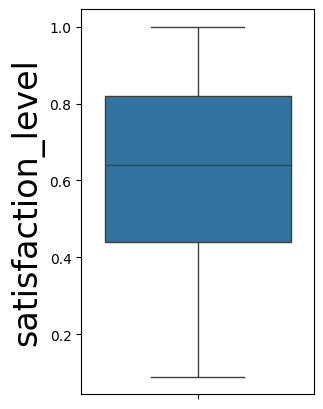

In [197]:
print(df['satisfaction_level'].describe())

# because the fig size has to vary over the course of this presentation I set it in each figure,
# instead of through the environmental variable figure.figsize
fig, axs = plt.subplots(1, 1, figsize=(3,5))

#sns.scatterplot(data=df, x='satisfaction_level', y='left')
sns.boxplot(df, y='satisfaction_level')
# plt.xticks(rotation=30)

För att undersöka om det finns ett kluster vid extremt låg satisfaction så påvisar jag det genom siffror nedan

In [ ]:
df[df["satisfaction_level"] < 0.2]["satisfaction_level"].value_counts()


satisfaction_level
0.10    358
0.11    335
0.09    195
0.16     79
0.15     76
0.19     74
0.14     73
0.17     72
0.18     63
0.13     54
0.12     30
Name: count, dtype: int64

### Undersöka korrelationer
Kopplat framförallt till satisfaction_level vill jag försöka hitta korrelationer. Jag inleder med att visa upp alla relevanta attribut.

plots: 13
rows: 2
columns: 5,
before flatten(2, 5)
after flatten(10,)
0 last_evaluation
1 number_project
2 average_montly_hours
3 time_spend_company
4 Work_accident
5 left
6 promotion_last_5years
7 salary
8 hour_bins
9 last_eval_bins


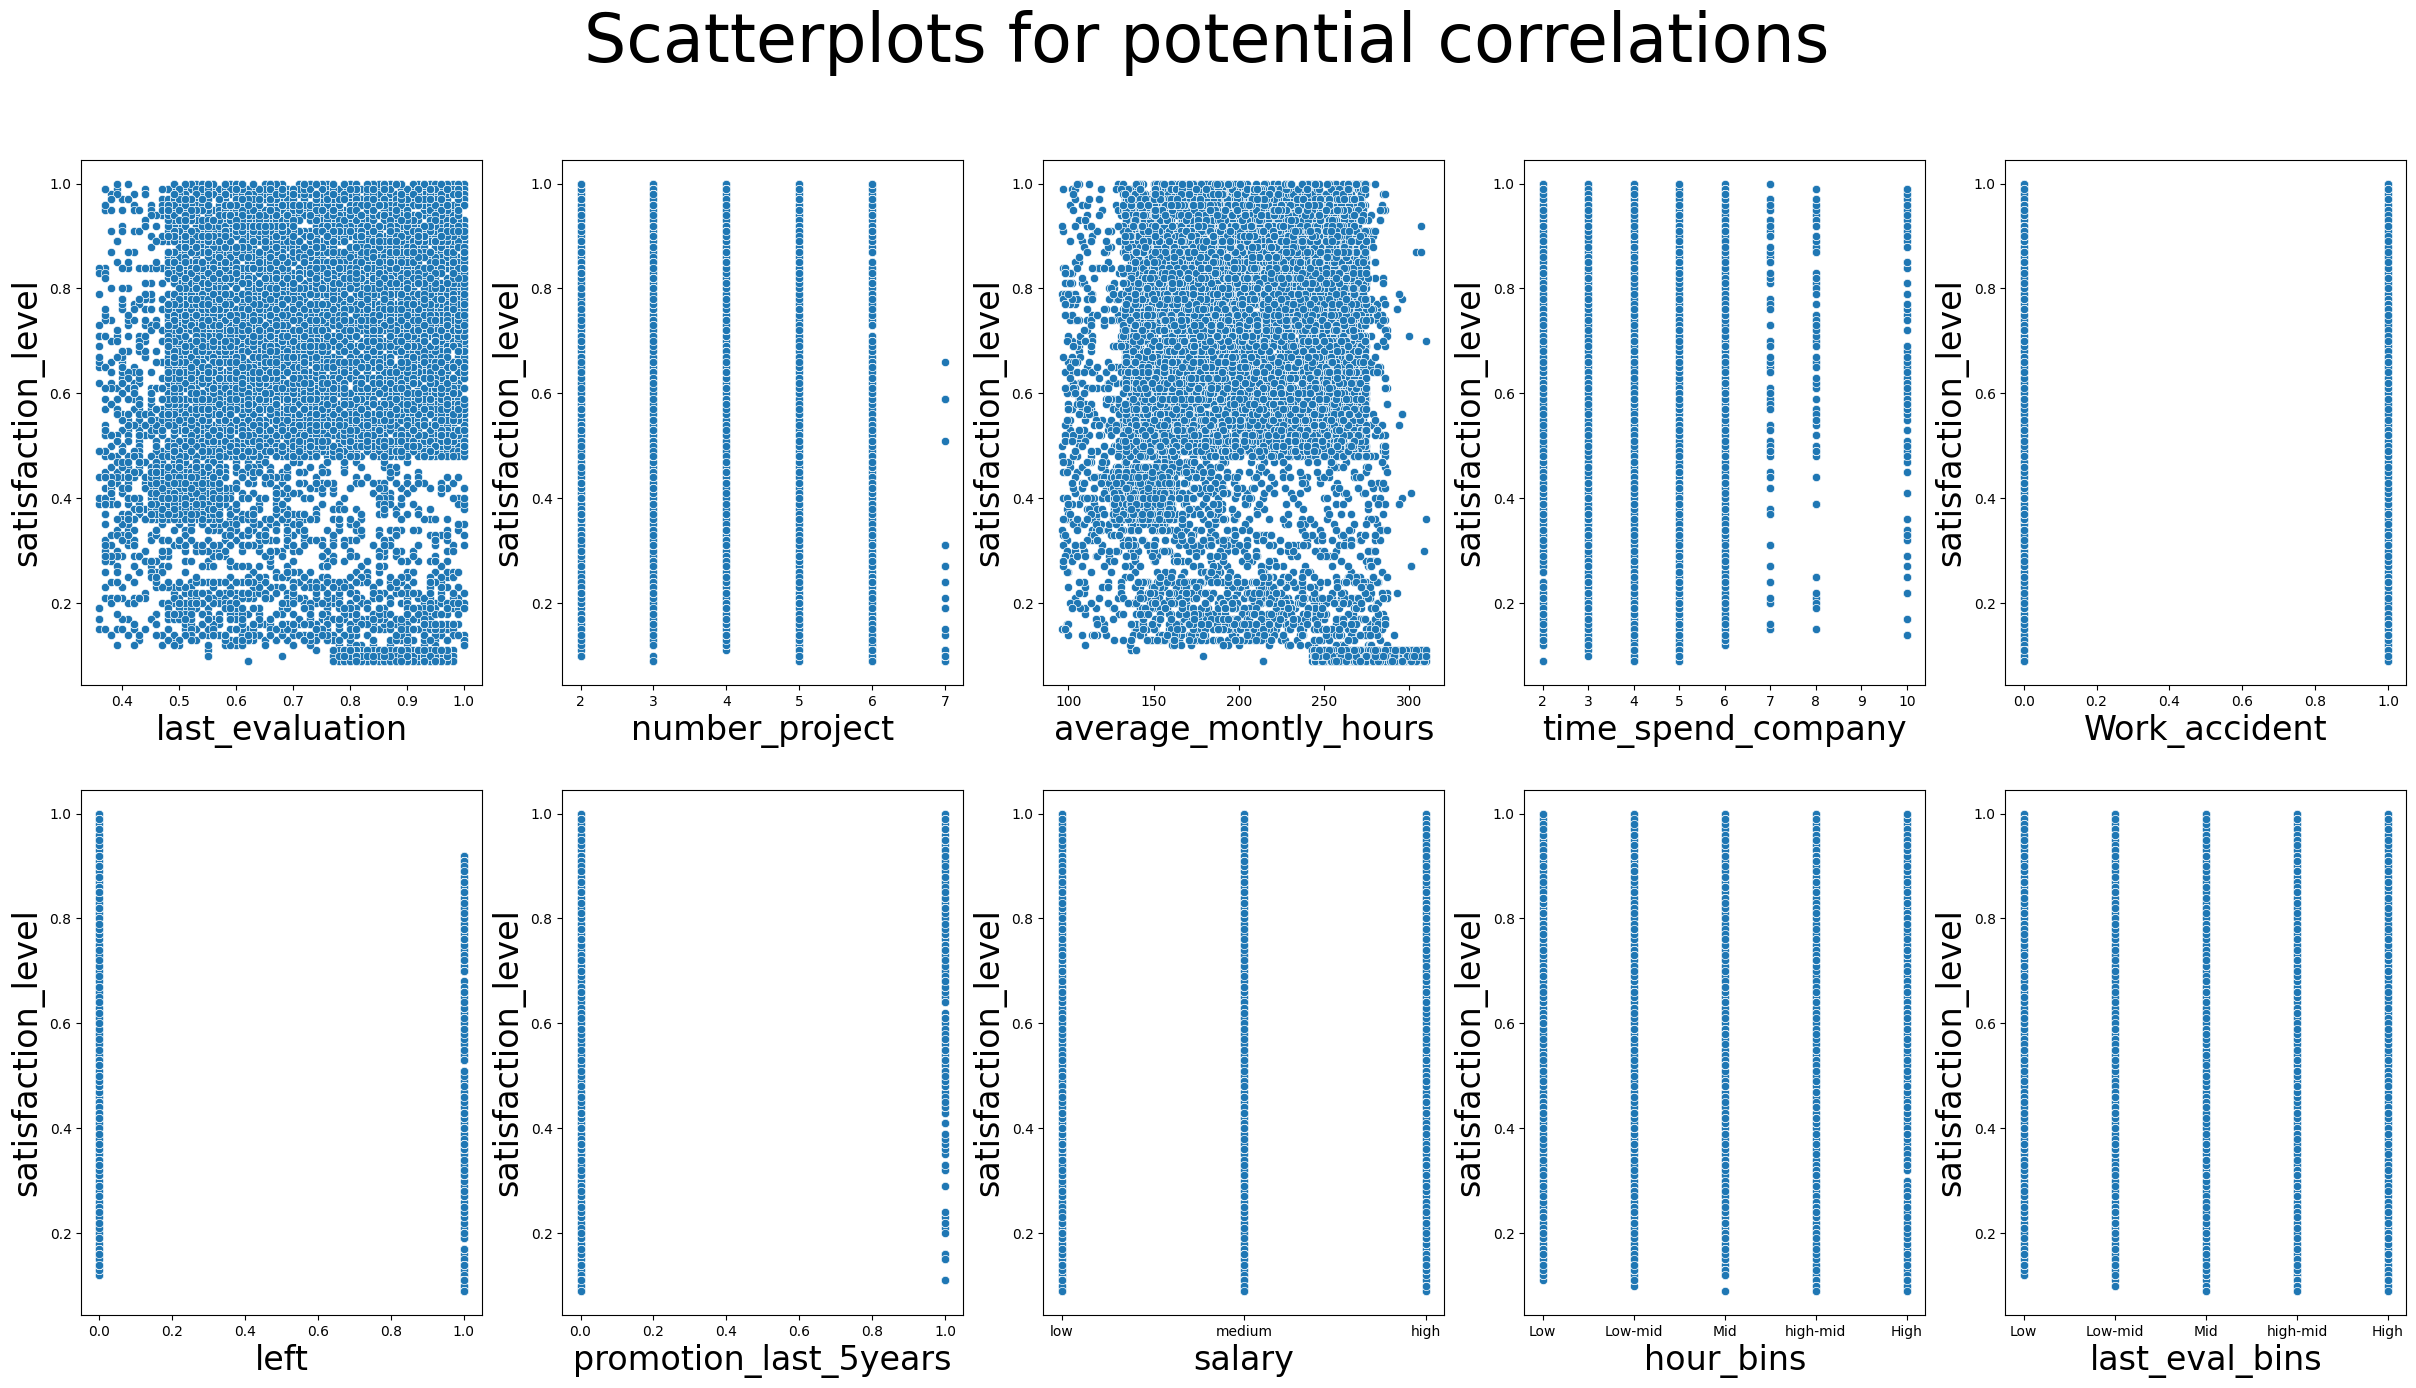

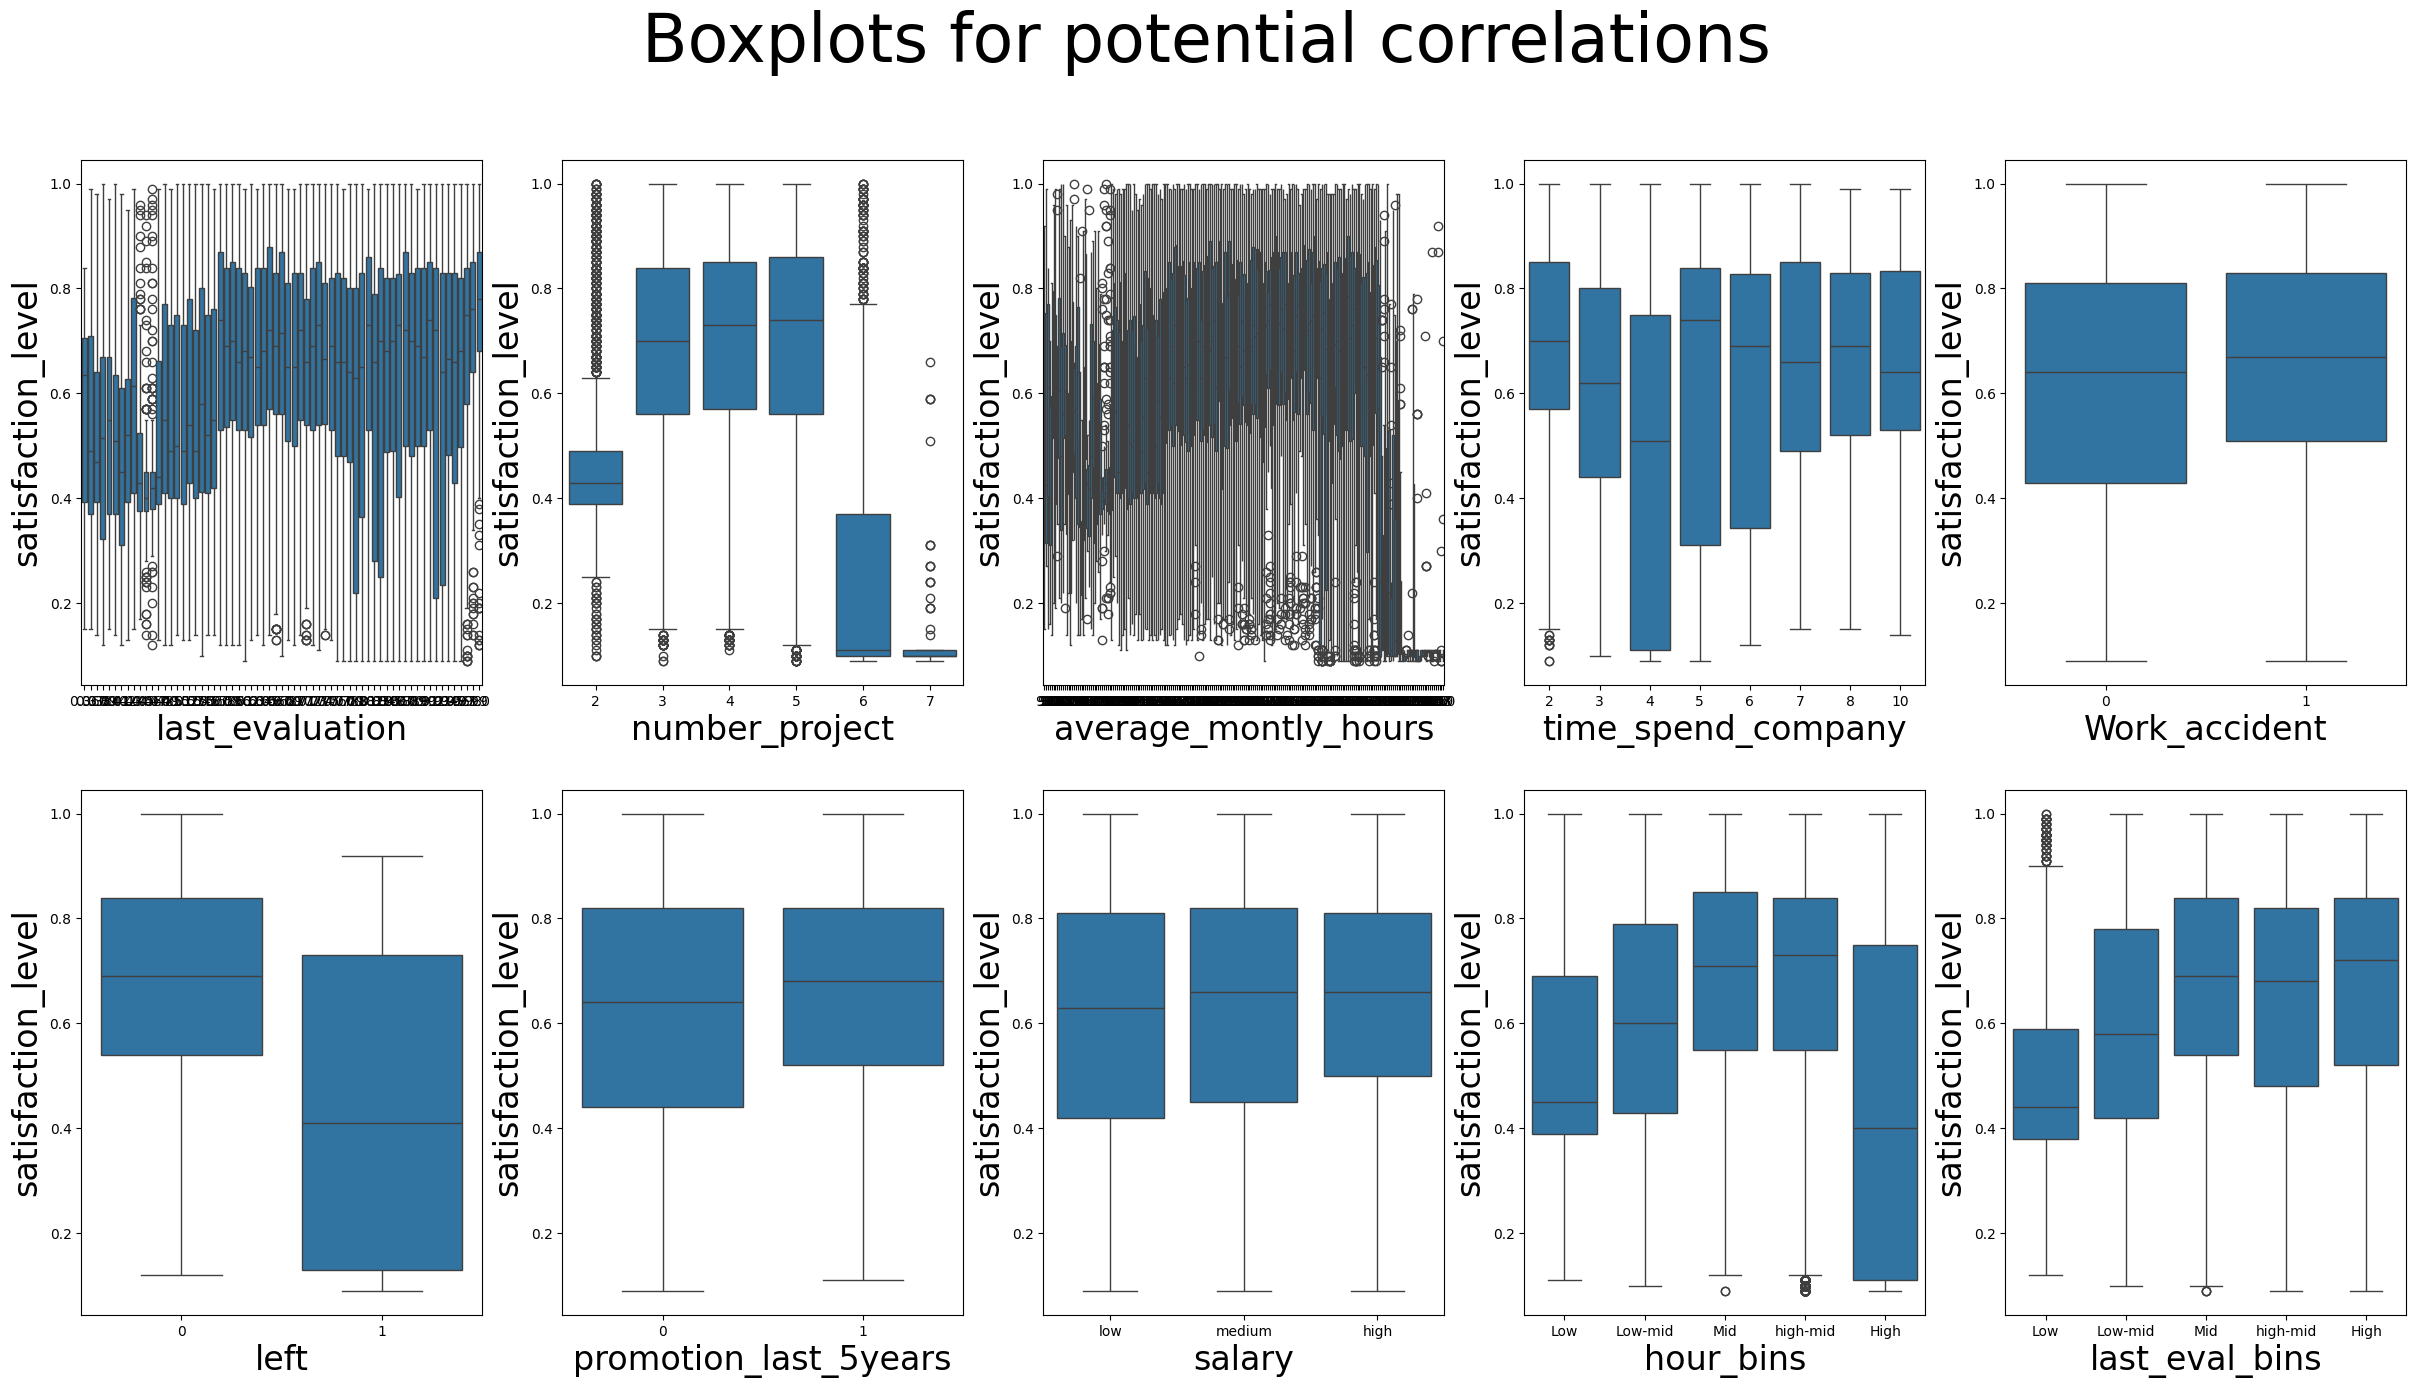

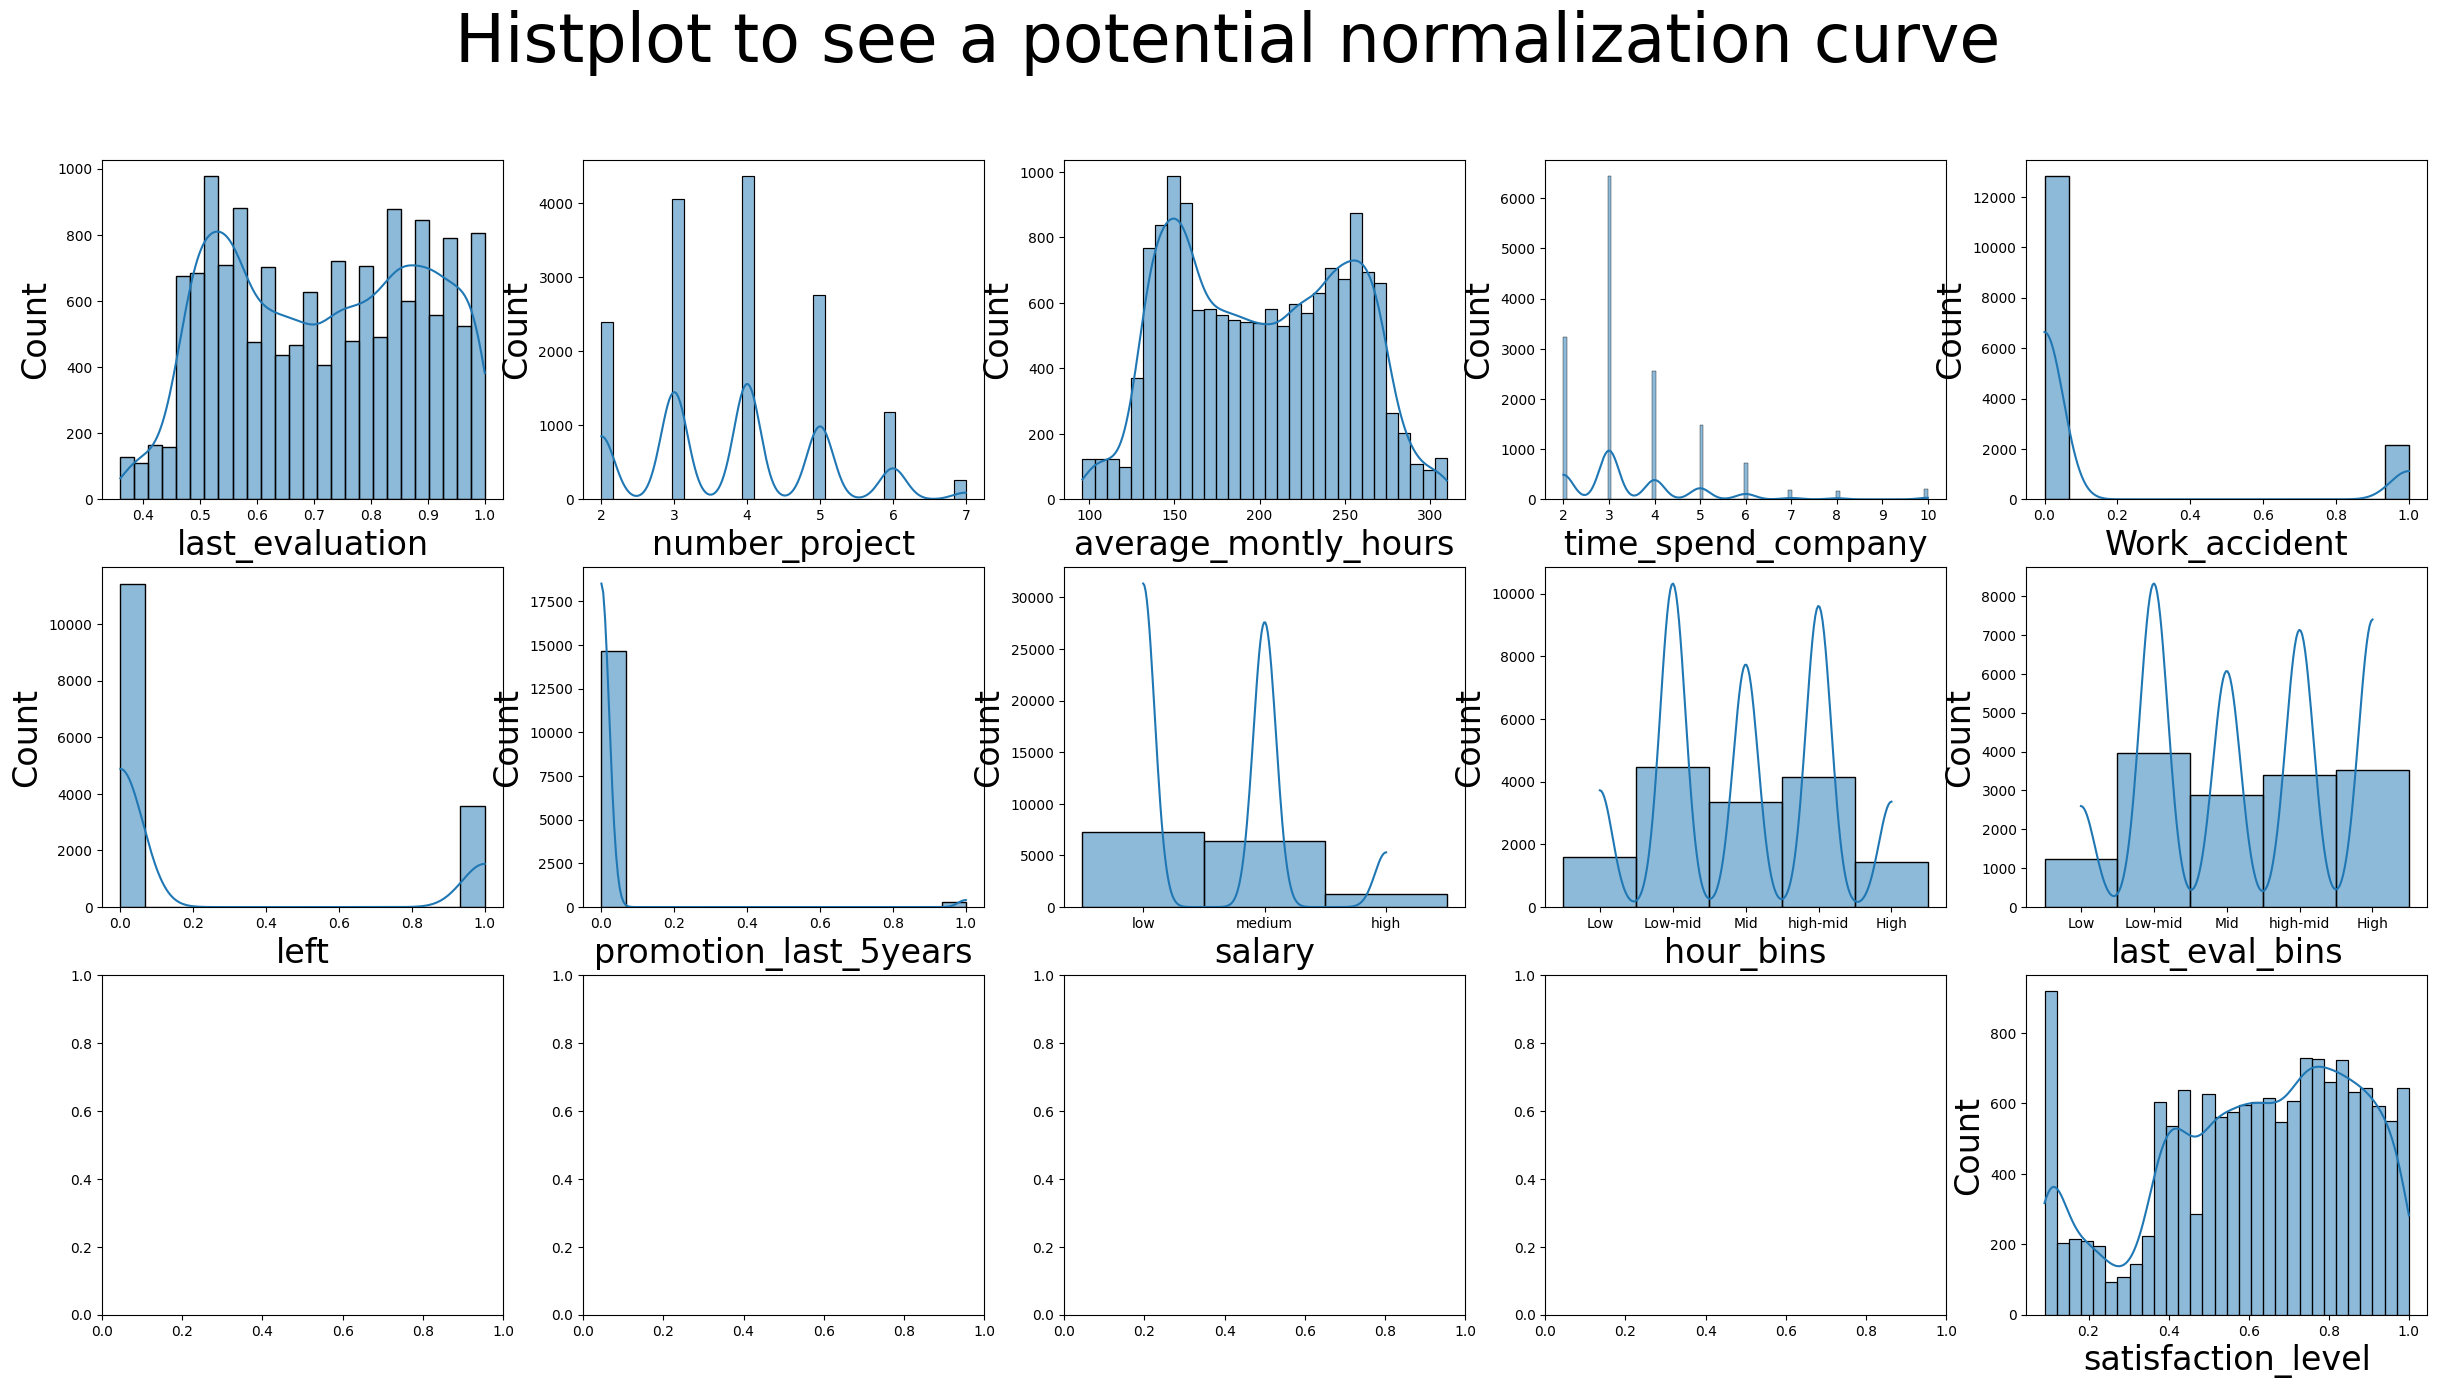

In [206]:

class Correlationplots:
    """Displays graphs for visualisation of dataset"""
    def __init__(self):
        # -2 because dont compare id and satisfaction_level
        self.dont_use = ['Emp_Id','Department','satisfaction_level']
        self.num_of_plot_rows = 2
        self.num_of_plots_to_execute = (len(list(df)))
        self.num_of_plot_cols = math.ceil((len(list(df)) - len(self.dont_use)) / self.num_of_plot_rows)

        # for no_use_headline in range (3):
        #     self.not_use.append(no_use_headline)
        # print(self.not_use)
        # print(list(df))
        print(f'plots: {self.num_of_plots_to_execute}\nrows: {self.num_of_plot_rows}\ncolumns: {self.num_of_plot_cols},')


    def draw_scatterplot(self):
        """Visualising utilising matplotlib.pyplot.subplots and seaborn.scatterplot"""
        # categorical values are not well visible in scatterplots
        fig, axs = plt.subplots(self.num_of_plot_rows, self.num_of_plot_cols, figsize=(30,15))
        
        # for the plot to be less dense
        # fig.tight_layout()

        # axs has too many dimensions by default but has to be such for correct UI
        # since df is 1 dimensional when unpacked below
        # error message was: "'numpy.ndarray' object has no attribute 'xaxis'"
        print("before flatten" + str(axs.shape))
        axs = axs.flatten()
        print("after flatten" + str(axs.shape))

        fig.suptitle("Scatterplots for potential correlations", fontsize=48)
        
        for num, headline in enumerate(list(df.drop(self.dont_use, axis=1))):
            print(num, headline)
            sns.scatterplot(data=df, y='satisfaction_level', x=headline, ax=axs[num])
        

    def draw_boxplot(self):
        """Visualising utilising matplotlib.pyplot.subplots and seaborn.boxplot"""
        fig, axs = plt.subplots(self.num_of_plot_rows, self.num_of_plot_cols, figsize=(30,15))

        axs = axs.flatten()

        fig.suptitle("Boxplots for potential correlations", fontsize=48)

        
        for num, headline in enumerate(list(df.drop(self.dont_use, axis=1))):
            # print(num, headline)
            sns.boxplot(data=df,
                        y='satisfaction_level',
                        x=headline,
                        ax=axs[num])
            
    def draw_normalisationcurve(self):
        """Visualising utilising matplotlib.pyplot.subplots and seaborn.histplot"""
        # this time +1 to also fit a plot of satisfaction_level
        fig, axs = plt.subplots(self.num_of_plot_rows + 1, self.num_of_plot_cols, figsize=(30,15))

        axs = axs.flatten()

        fig.suptitle("Histplot to see a potential normalization curve", fontsize=48)

        
        for num, headline in enumerate(list(df.drop(self.dont_use, axis=1))):
            # print(num, headline)
            sns.histplot(data=df,
                        x=headline,
                        kde=True, # a smooth line included
                        ax=axs[num])
            
        # create an extra for satisfaction_level
        sns.histplot(data=df,
                    x='satisfaction_level',
                    kde=True,
                    ax=axs[-1])
        
    # def draw_lines_against_satisfaction(self):
    # """Displays two curves in order to see correlations against satisfaction_level"""
    #     fig, axs = plt.subplots(self.num_of_plot_rows, self.num_of_plot_cols, figsize=(30,15))

    #     axs = axs.flatten()

    #     fig.suptitle("Histplot to see a potential normalization curve", fontsize=48)

        
    #     for num, headline in enumerate(list(df.drop(self.dont_use, axis=1))):
    #         # print(num, headline)
    #         sns.histplot(data=df,
    #                     x=headline,
    #                     y='satisfaction_level',
    #                     kde=True, # a smooth line included
    #                     ax=axs[num])
            

# run the different methods
corr_plot = Correlationplots()
corr_plot.draw_scatterplot()
corr_plot.draw_boxplot()
corr_plot.draw_normalisationcurve()
# corr_plot.draw_lines_against_satisfaction()


##### Förbättrar visibiliteten
Eftersom vissa av ovan boxplot är svåra att se, då de består av löpande variabler, så gör jag istället en kategorisering av dessa.
Jag ser Last_evaluation som företagets skattning av den anställning

<Axes: xlabel='last_eval_bins', ylabel='satisfaction_level'>

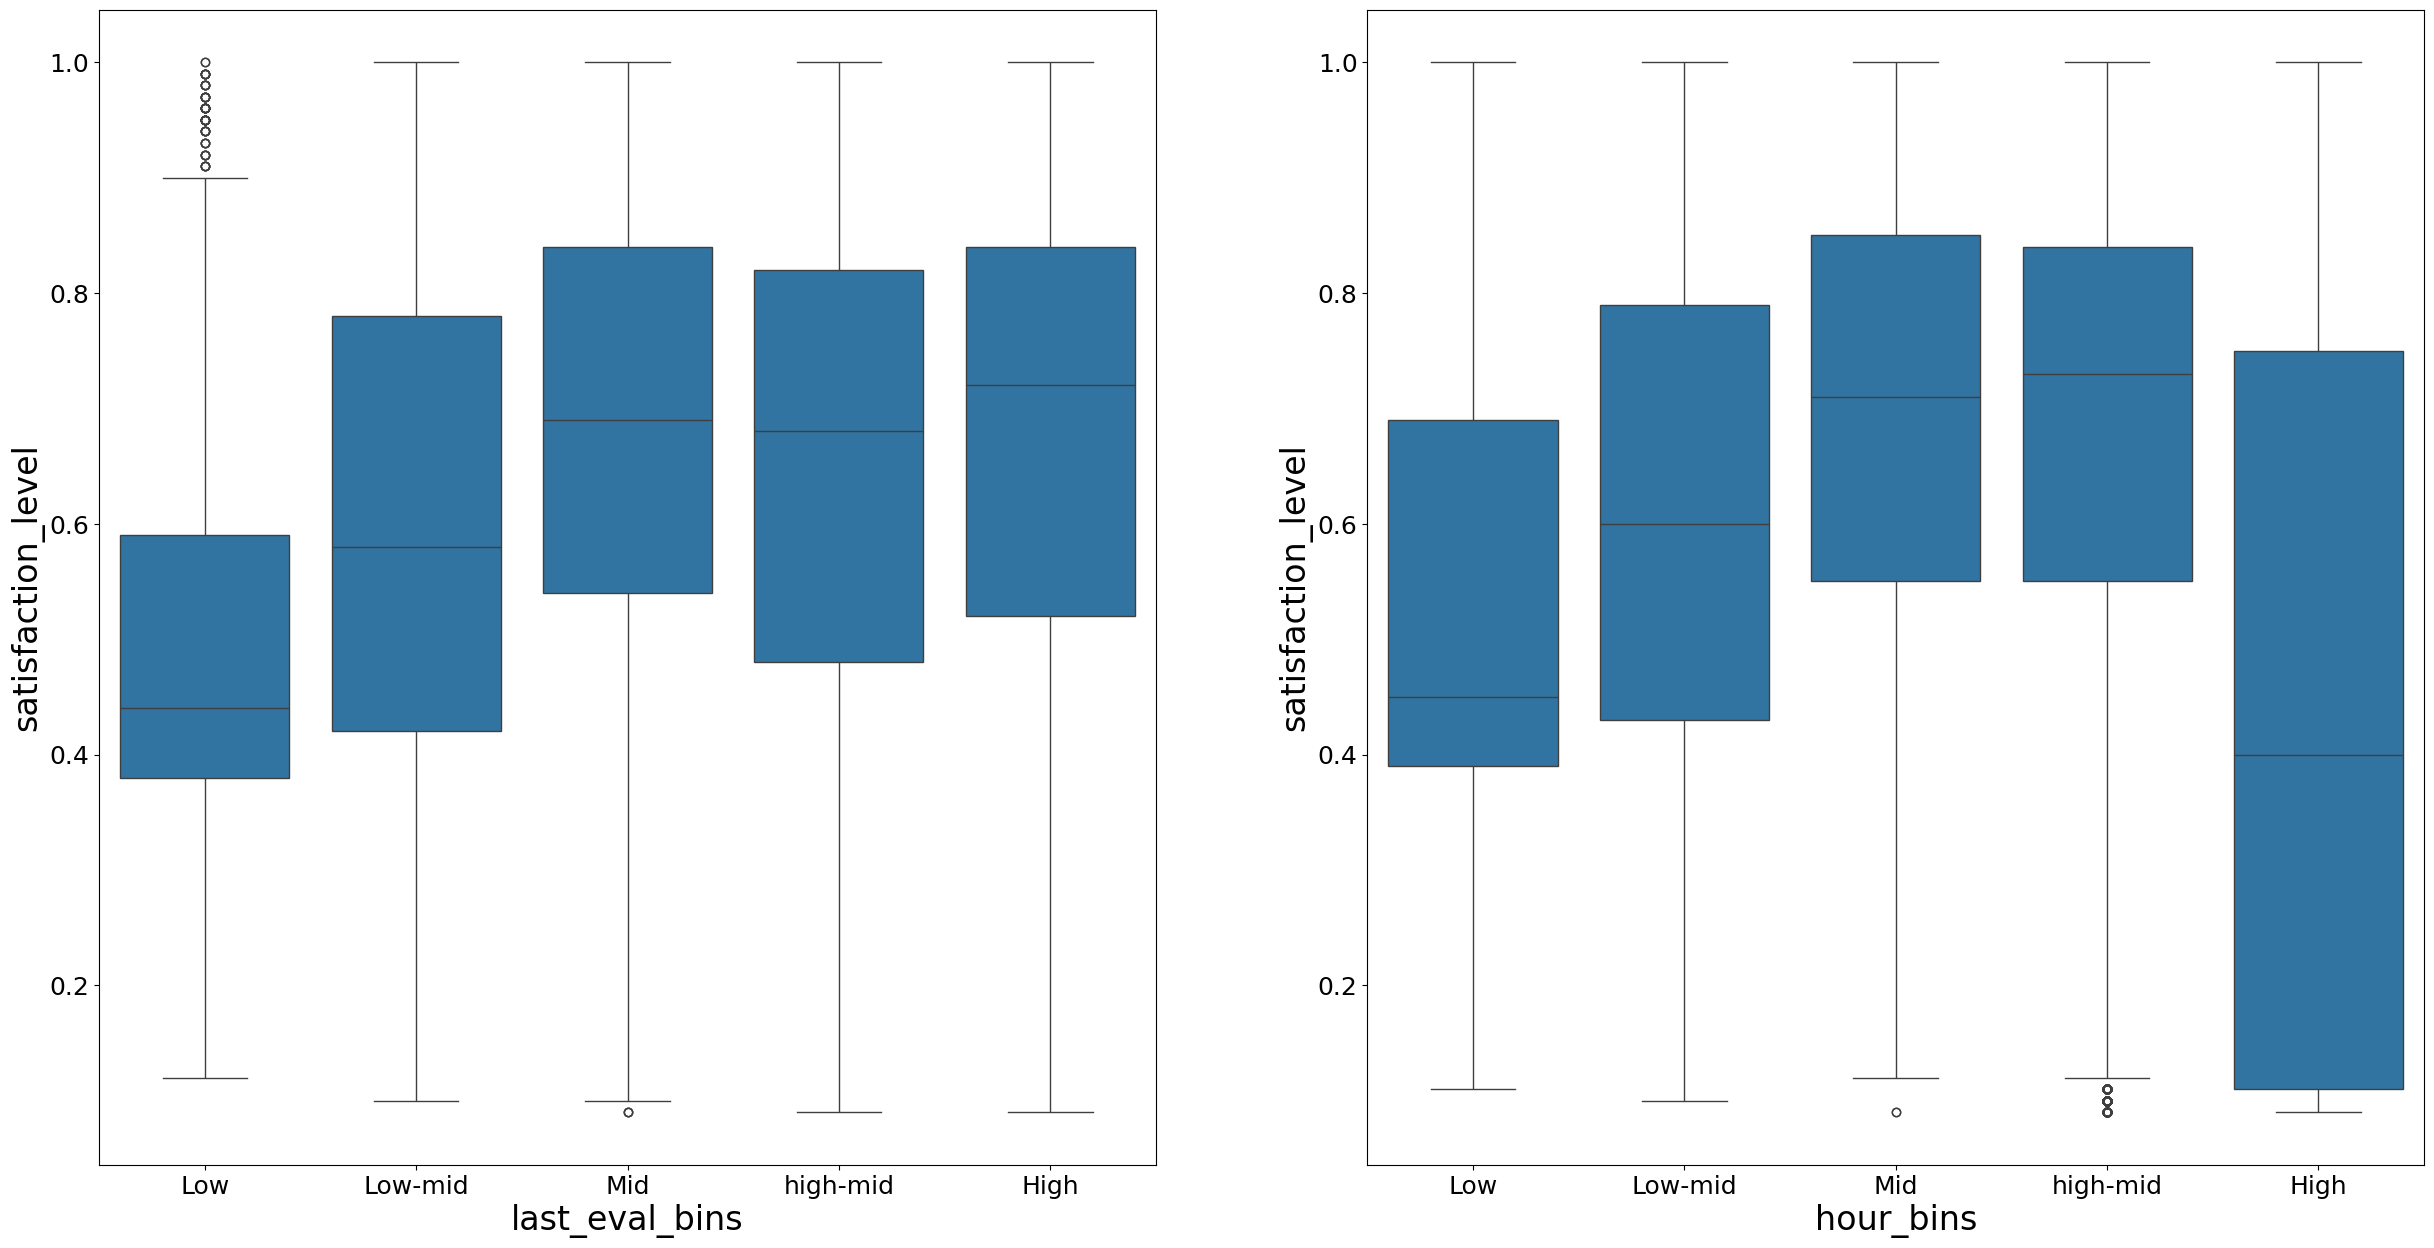

In [259]:
df['hour_bins'] = pd.cut(df['average_montly_hours'], bins=5, retbins=False, labels=["Low", "Low-mid", "Mid", "high-mid", "High"])
df['last_eval_bins'] = pd.cut(df['last_evaluation'], bins=5, retbins=False, labels=["Low", "Low-mid", "Mid", "high-mid", "High"])

fig, axs = plt.subplots(1, 2, figsize=(30, 15))
sns.boxplot(df, x='hour_bins', y='satisfaction_level', ax=axs[1])
sns.boxplot(df, x='last_eval_bins', y='satisfaction_level', ax=axs[0])


Denna graf visar skillnaderna mellan de som slutat och de som fortfarande arbetar kvar, ställt mot nöjdhet resp last_evaluation

<Axes: xlabel='last_eval_bins', ylabel='Count'>

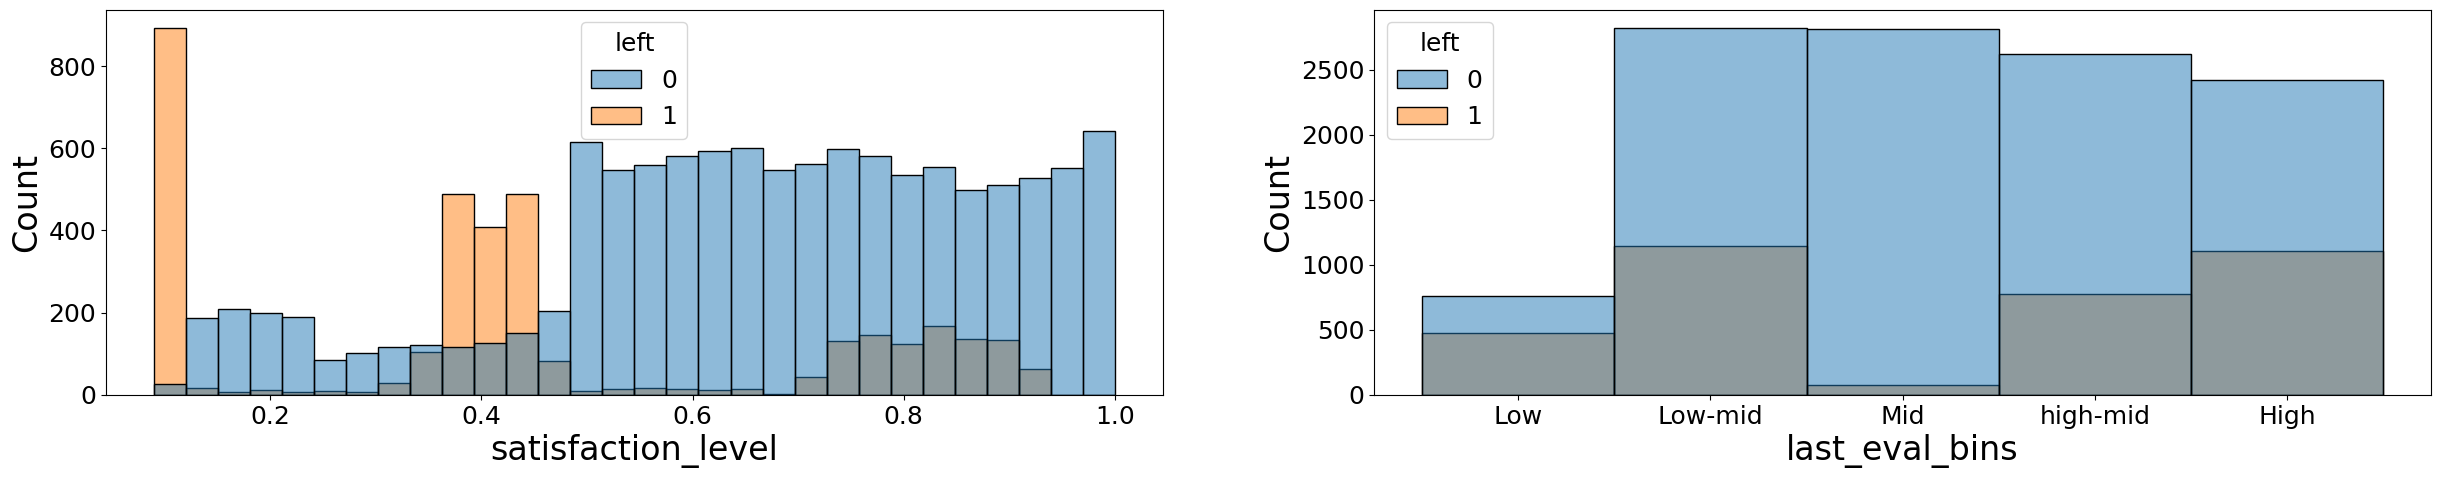

In [260]:
fig, axs = plt.subplots(1,2, figsize=(30, 5))

# Skapar en ny visuell dimension genom hue
# värdena som ligger nära noll eller väldigt långt ner är också intressanta
sns.histplot(data=df, x="satisfaction_level", hue='left', ax=axs[0])
sns.histplot(data=df, x="last_eval_bins", hue='left', ax=axs[1])


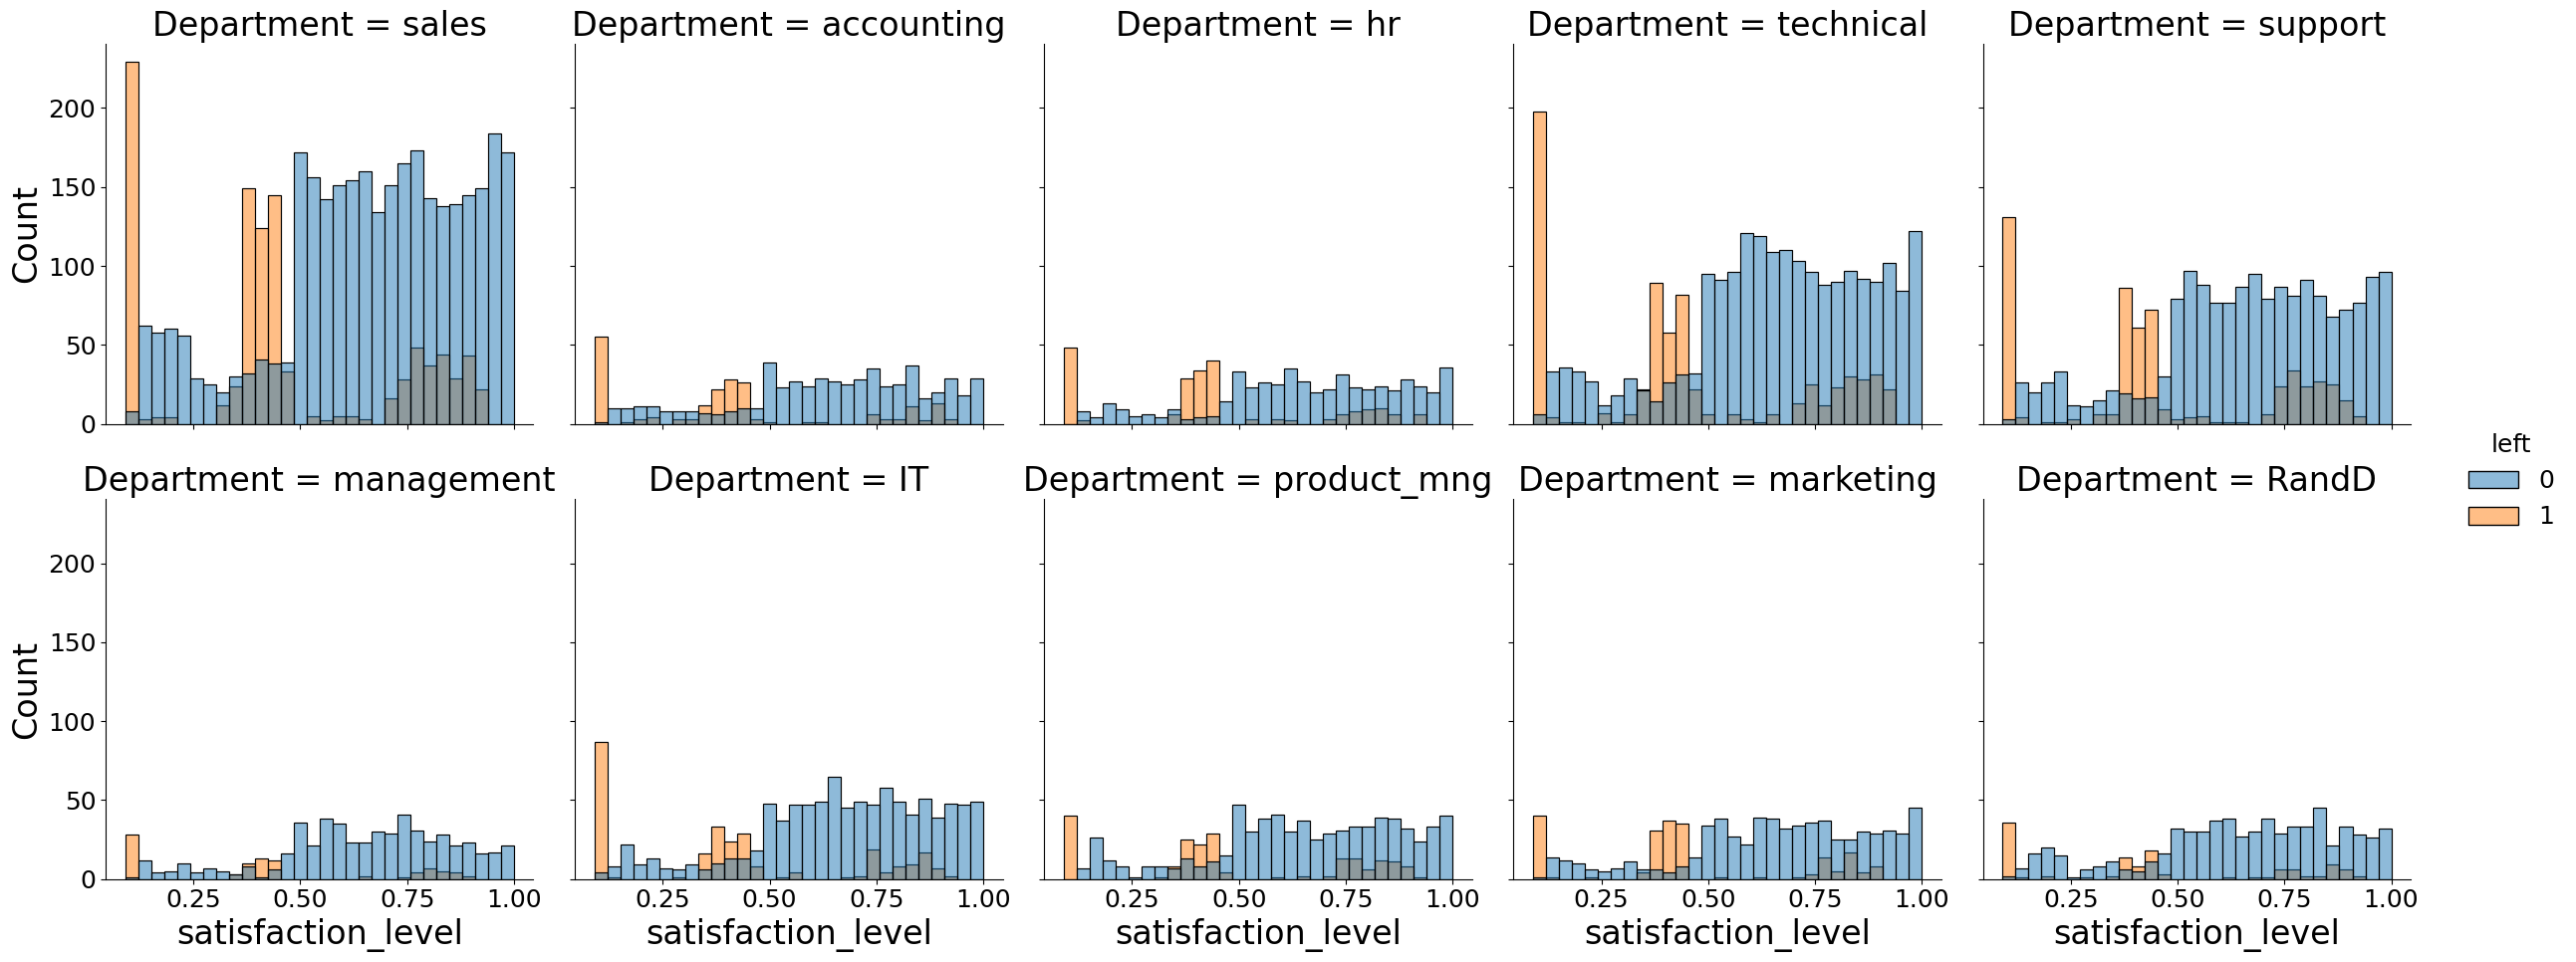

In [267]:
# satisfaction_level
# inspo_ https://seaborn.pydata.org/tutorial/relational.html#plotting-subsets-of-data-with-semantic-mappings
# https://seaborn.pydata.org/tutorial/distributions.html#conditioning-on-other-variables
sns.displot(data=df,
            x='satisfaction_level', # grafen är i sin ursprungsform endimensionell
            hue='left', # skapar en andra dimension genom olika färger, baserat på de två värdena i om man slutat eller inte
            col='Department', # skapar en graf per avdelning
            col_wrap=5,
            )

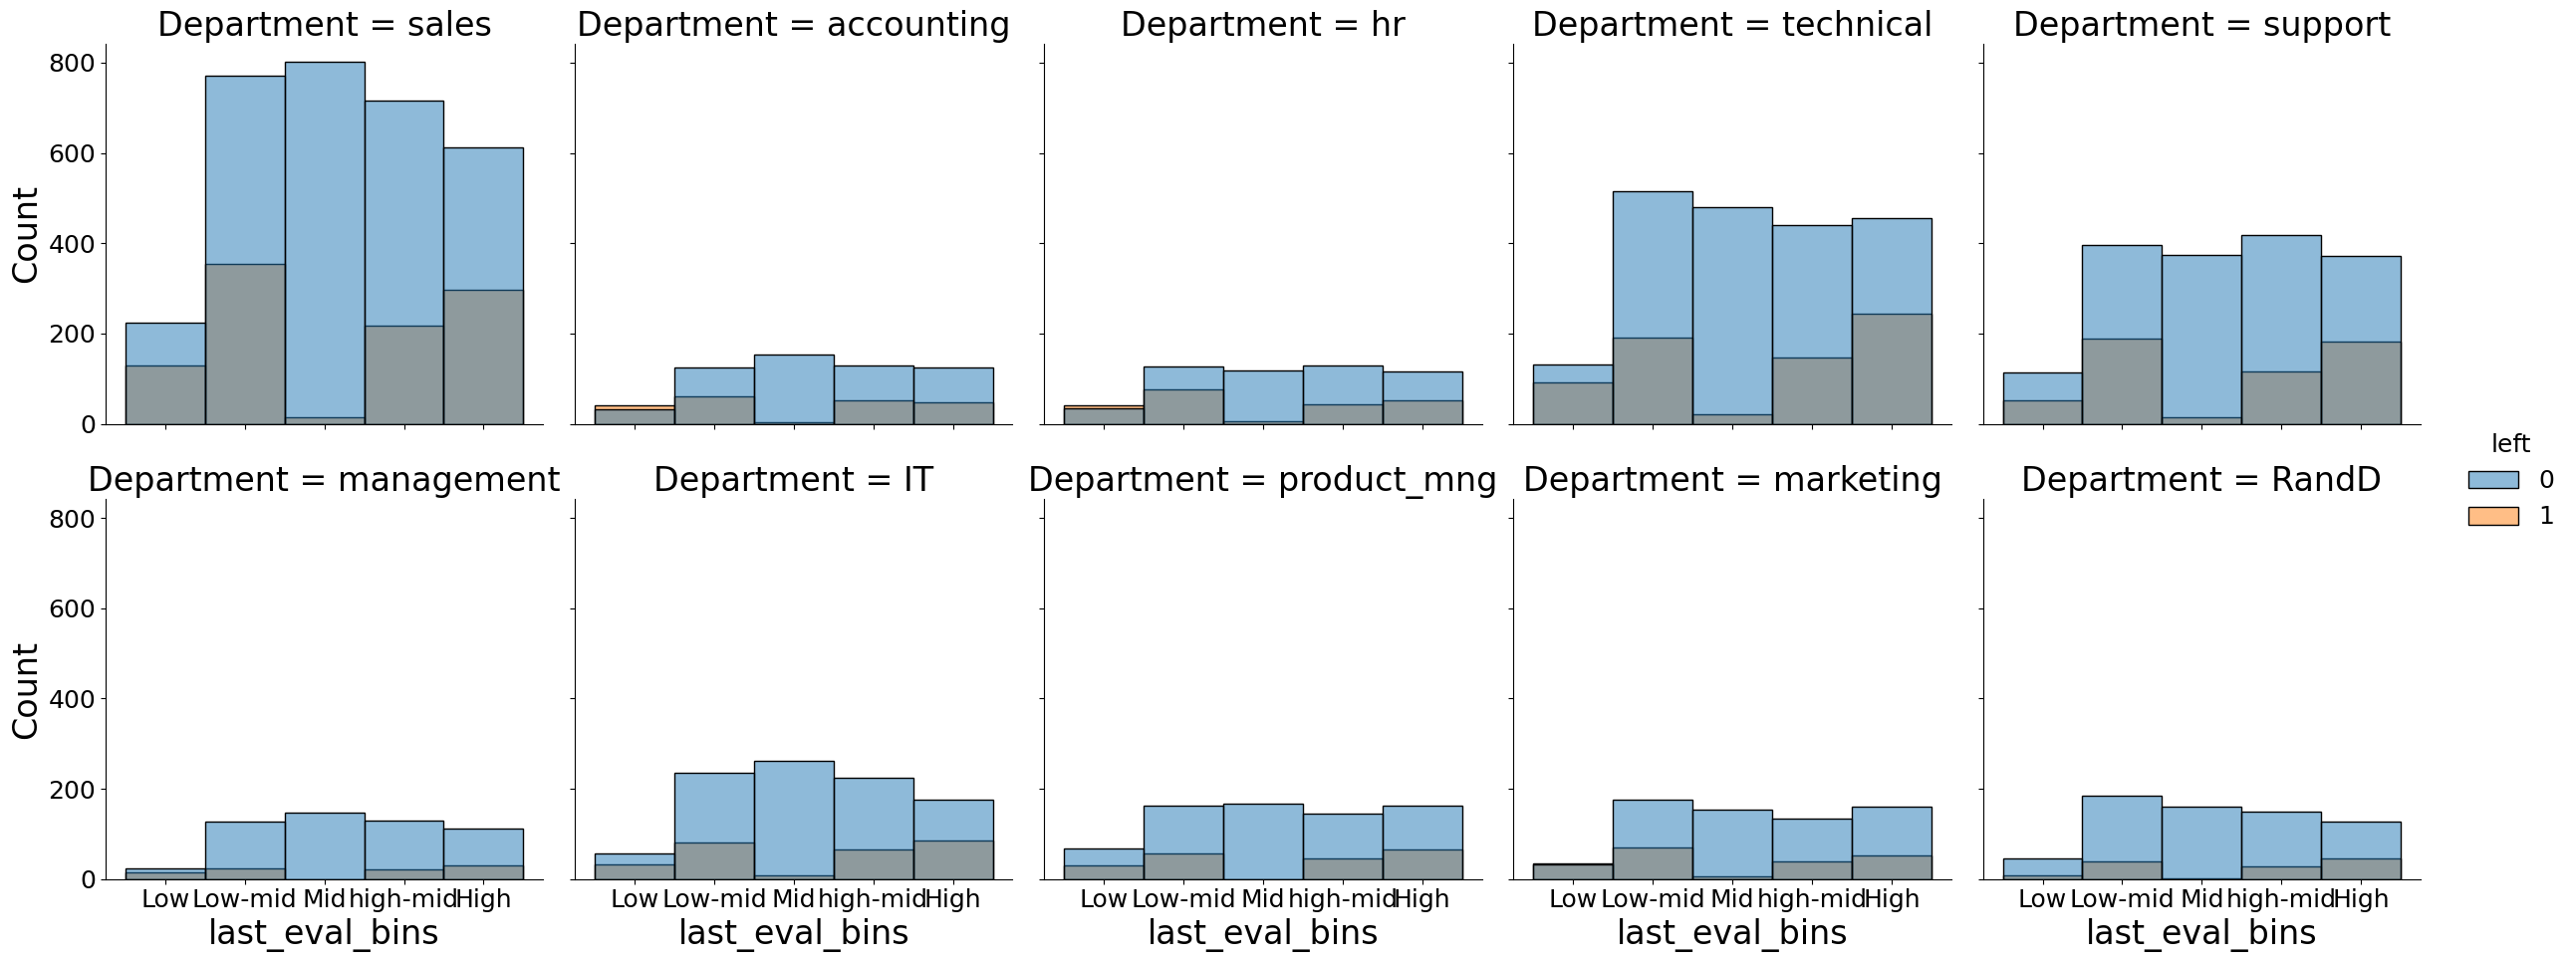

In [268]:
# satisfaction_level
# inspo_ https://seaborn.pydata.org/tutorial/relational.html#plotting-subsets-of-data-with-semantic-mappings
# https://seaborn.pydata.org/tutorial/distributions.html#conditioning-on-other-variables
sns.displot(data=df,
            x='last_eval_bins', # grafen är i sin ursprungsform endimensionell
            hue='left', # skapar en andra dimension genom olika färger, baserat på de två värdena i om man slutat eller inte
            col='Department', # skapar en graf per avdelning
            col_wrap=5,
            )

([<matplotlib.patches.Wedge at 0x7863d7ae8e00>,
 [Text(0.4529082920499383, 0.5337359637427552, 'sales'),
  Text(-0.468471324808876, 0.5201294241165525, 'technical'),
  Text(-0.6861879735505865, -0.13836930640333378, 'support'),
  Text(-0.42248411036138384, -0.5581282796025928, 'IT'),
  Text(-0.14045253327734575, -0.6857645994770918, 'product_mng'),
  Text(0.11609559183615699, -0.6903055943248704, 'RandD'),
  Text(0.34243944246715863, -0.6105204568585574, 'marketing'),
  Text(0.5196876084274429, -0.46896139462322994, 'accounting'),
  Text(0.6395335819433599, -0.2845993632577133, 'management'),
  Text(0.693914553635467, -0.0921009894240592, 'hr')],
 [Text(0.8734659918105955, 1.0293479300753137, '27.6%\n(3154)'),
  Text(-0.9034804121314037, 1.0031067465104941, '18.1%\n(2072)'),
  Text(-1.3233625204189883, -0.26685509092071513, '14.9%\n(1698)'),
  Text(-0.814790784268383, -1.0763902535192862, '8.2%\n(935)'),
  Text(-0.27087274274916684, -1.3225460132772484, '6.0%\n(687)'),
  Text(0.2238986

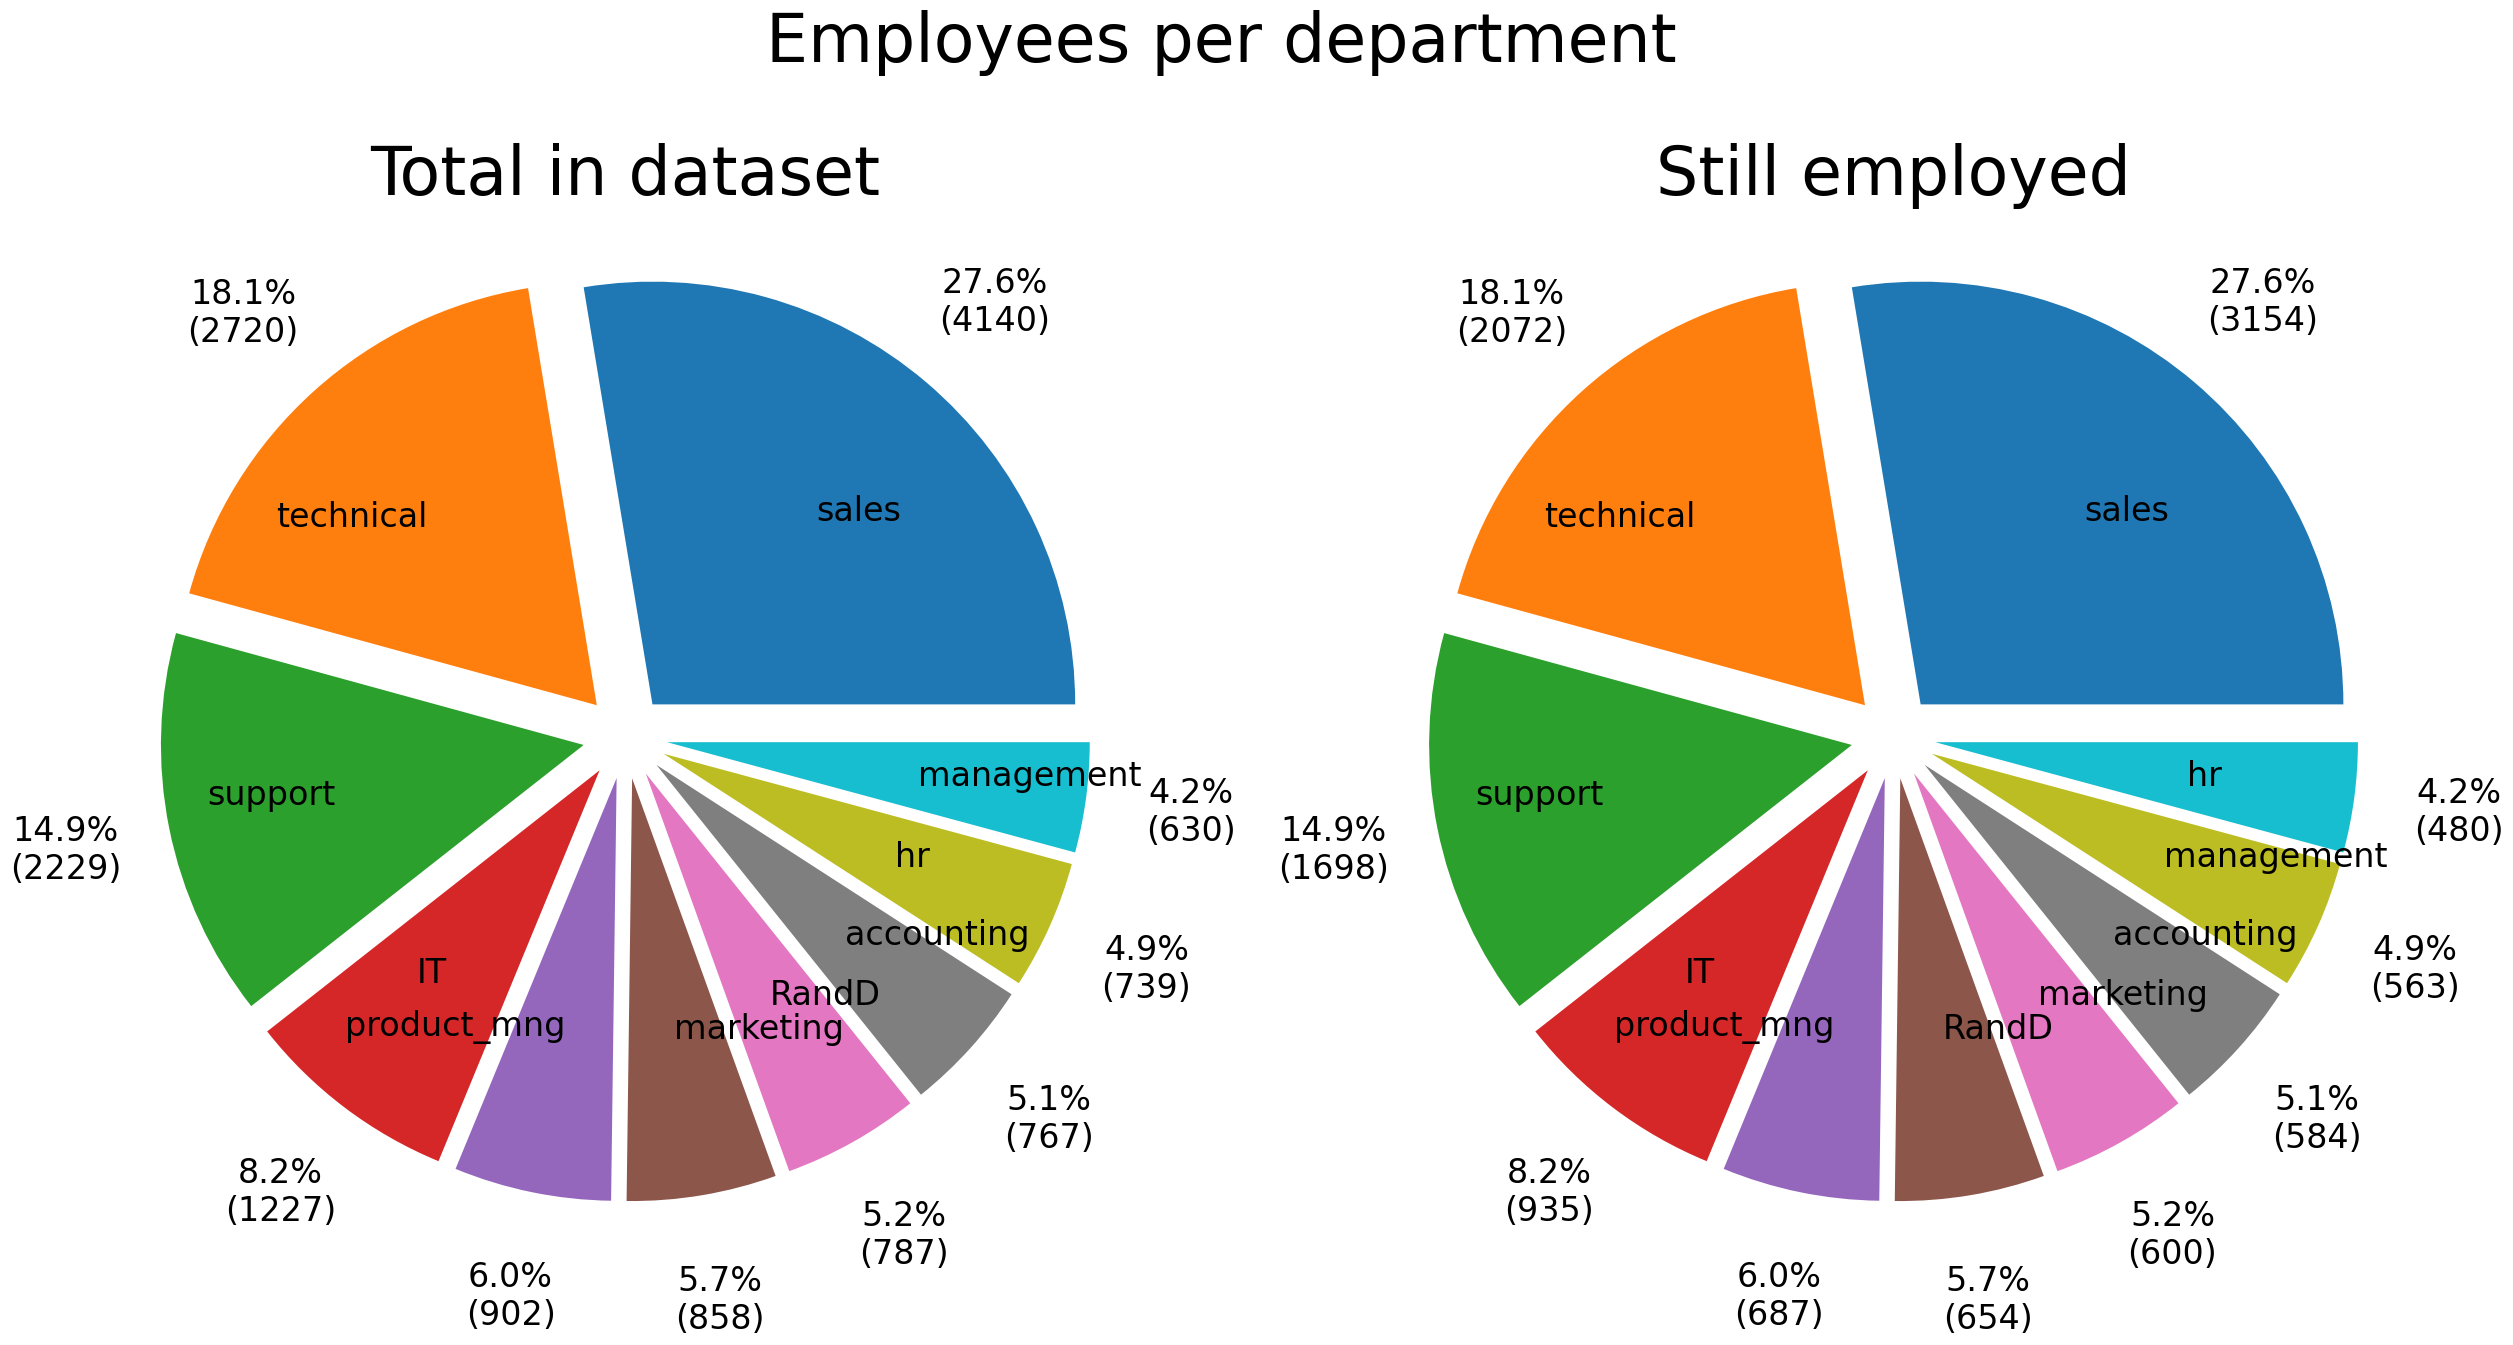

In [261]:
# https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html
fig, axs = plt.subplots(1, 2, figsize=(30, 15))
fig.suptitle('Employees per department', fontsize=48)


def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

amount_department = df['Department'].value_counts()
amount_department_has_left = df[df['left'] == 1]['Department'].value_counts()
amount_department_not_left = df[df['left'] == 0]['Department'].value_counts()
# print(amount_department)
# print()
# print(amount_department_has_left)
# print(amount_department_not_left)

# df[df["satisfaction_level"] < 0.2]["satisfaction_level"].value_counts()
axs[0].title.set_text("Total in dataset")
axs[0].pie(amount_department, 
        labels=amount_department.index,
        autopct=autopct_format(amount_department),
        pctdistance=1.25,
        labeldistance=.6,
        explode=(0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1),
        textprops={'fontsize':24}
        )
# Total amount who still works here
axs[1].title.set_text('Still employed')
axs[1].pie(amount_department, 
        labels=amount_department_not_left.index,
        autopct=autopct_format(amount_department_not_left),
        pctdistance=1.25,
        labeldistance=.6,
        explode=(0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1),
        textprops={'fontsize':24}
        )

## Analys
Jag tänkte här stanna upp och göra en analys av vad jag hittat hittills.
Klart är iaf att det inte finns några solklara korrelationer. Det finns i vissa fall starka indikatorer på grupperingar och / eller korrelationer. Mer om det nedan.
Ingen av attributen är normalfördelade, vilket jag tänker inte säger så mycket. Eventuellt att personalstyrkan är heterogen i sin gruppdynamik?

### Outliers
I bl a last_evaluation finns en del outliers. Dessa kan indikera på fel men de kan också indikera på att det är en väldigt stor spridning och diskrepans mellan vad den anställde tycker om sin arbetsplats och vad cheferna tycker om den anställde. Jag har inte riktigt hittat några outliers som skulle kunna behöva undersökas närmre.

### samband
Jag tycker att jag ser ett tydlig samband mellan satisfaction_level och ...:
- **många arbetstimmar per månad**. Det är ju ingen chock att om man jobbar länge blir man trött. Kanske känner denna grupp sig dessutom pressad eller står utan valmöjlighet, vilket är en annan faktor för sämre mående. Det kan ju också vara personer som arbetar många timmar för att de behöver vila hjärnan från det som stressar de privat. Då är man också extra beroende av hur arbetsplatsen får en att må, kanske har man också en mer avslagen eller rent negativ känsla för det mesta?
- **time_spent_company** har ett tydligt samband vid 4 (jag antar att det är år) för negativ uppfattning av arbetsplatsen. Denna grupp är också ganska stor och har en relativt sina andra kategorier en stor spridning, som tenderar mot det negativa. Jag skulle vilja att HR tittar närmre på denna grupp för att se om det finns några inbördes problem här.
- **number_projects** visar mycket tydligt att man blir missnöjd ju fler projekt man har. Det är också ett litet fåtal som har en stor mängd projekt, vilket kanske i sin tur skapar en känsla av orättvisa. I den kategorin där man har flest antal projekt så är också nästan alla väldigt missnöjda.
- attributet **left** ser jag som att personerna har lämnat företaget. Det finns två ganska tydliga grupperingar bland de som slutat, både i last_evaluation och satisfaction_level. Denna uppdelning finns inte när det kommer till de som fortfarande arbetar kvar. Det hade varit intressant att koppla detta mot en uppgift om de blivit uppsagda eller slutat själva.
  - Det naturliga är väl att om man är missnöjd så lämnar man till slut företaget. Om undersökningarna gjorts årligen så kan man ju ha hunnit med att lämna efter två undersökningar och jag tänker då att man inte ökat i sin nöjdhet. Det vore intressant att studera hur nöjdheten har varierat över tid för de som varit anställda längre än tre år (och därmed garanterat kommit förbi två stycken årliga medarbetarundersökningar)
  - kan det vara så att värderingen antingen har fått folk att sluta eller kan det vara så att man varit missnöjd med arbetet, släpat benen efter sig och sedan blivit uppsagd? Dessa två kategorier är känsliga att utreda men mätetal för mobbing kan vara mycket viktigt för ett företag

En anmärkningsvärd insikt är att högre lön inte ger högre nöjdhet. Lönen är iofs säkerligen uträknad mot företagets snitt men det visar ju på att de anställda som vet vad kollegorna tjänar (vilket inte är många, utöver ekonomiavdelningen) tycker att det känns ok.

### punktdiagrammen
Visar inte på några tydliga trender. Möjligen ett behov att rensa datan då fyrkantiga samlingar av data uppenbarar sig på två ställen.

### Beskrivningar
Detta är mer egna minnesanteckningar kopplat till denna uppgift
#### Boxplots - lådagram
[Inspo](https://www.matteboken.se/lektioner/matte-2/statistik/kvartiler-och-ladagram#!/)<br>
Det svarta strecket i den blåa "lådan" är medianvärdet<br>
Den blåa "lådan" är 50% av alla värden, det är avståndet mellan den nedre och den övre kvartilen.<br>
Mellan de båda tvärstrecken <br>
##### Percentil
Är en hundradel av alla observationsvärden. Den nedre kvartilen är alltså p25 (den 25e percentilen)
#### Outliers
Man kan se att vi på flera av attributen har outliers. Det är värden som ligger (1.5*IQR) från medianvärdet (det svarta strecken i den blåa boxen).
Outliers är 1.5 gånger det interquartile range (IQR), vilket är avståndet mellan max / min i den färgade lådan, som innehåller 50% av alla dataounkter


### Hur många arbetar på respektive avdelning?
Här nedan delar vi upp värdena och utvärderingarna per avdelning. För det är det ju förstås intressant att se hur fördelningen mellan avdelningarna ser ut

Här vill jag visa på om satisfaction skiljer sig mellan de olika avdelningarna, inkluderat left

### Övriga slutsatser
#### Resultatbenägenhet
Man se att denna arbetsgivaren har ansträngt sig med att ta fram många siffror för att de facto på djupet försöka hitta orsak och samband till nöjda medarbetare. Jag skulle dock säga att det saknas en del som man i framtiden kan fundera på att tillägga.

### Vad ger nöjda medarbetare?
Efter lite snabb läsning så kan jag konstatera att nöjda medarbetare, som är en subjektiv undersökning, härstammar i trygghet på arbetsplatsen och hur mycket kontroll man känner över sina arbetsuppgifter och den kommunikation som sker inom företaget.

#### Referenser
##### [Examensarbete om nöjda medarbetare, Högskolan i Skövde](https://www.diva-portal.org/smash/get/diva2:651400/FULLTEXT01.pdf)
Påvisade genom enkätundersökning samband mellan upplevd kontroll på arbetsplatsen och kommunikationstillfredsställese (β = -.98) samt mellan välbefinnande och kommunikationstillfredsställelse (β = 1.43).
De som hade hög subjektiv upplevelse av kontroll föredrog elektroniska och skriftliga kommunikationsvägar.

##### [Magisteruppsats "Vikten av nöjda medarbetare"](https://gupea.ub.gu.se/bitstream/handle/2077/29608/gupea_2077_29608_1.pdf?sequence=1)
Författarinnan argumnenterar för att ett företags framgång avgörs av nöjda medarbetare. <br>
Hon jämför mellan tjänstemän och kollektivanställda i denna undersökning gjord på kommunala förvaltningar. <br>
Hon ser att ett företags alla aktiviteter sällan utgår från vad de anställda faktiskt skulle vilja förbättra, lära sig mer om eller fokusera på. Konkret tycker jag hon drar slutsatsen att företag skulle behöva arbeta med datadrivna beslut inom medarbetarnas behov för att utöra sina arbetsuppgifter - till skillnad från lön och teamaktiviter som automatisk go-to, vilket hon såg som vanligt.<br>
<br>
Hon ser att konkreta besparingar kan göras genom att helt enkelt lyssna. Således skulle jag säga att detta dataset på många sätt har svårt att svara på frågan om vad som påverkar de anställdas nöjdhet.<br>
<br>
Slutsatser: Några teman var tydliga påverkningsfaktorer när det kommer till de anställdas nöjdhet och motivation; bristande ledarskap, otillräcklig information, ojämn resursfördelning, utebliven feedback samt brister i den fysiska arbetsmiljön. Dessa borde man kunna mäta på olika sätt och tillägga den datan som man i ovan dataset skapat<br>

### Slutuppgifter
1. Vad har varit roligast i kunskapskontrollen? <br>
**Svar:**<br>
Jag tror det var när man, efter mycket slitande av håret, blev mer flytande i att tala diagrammiska. Jag har fortfarande mycket att lära men det känns som förberedelse inför analytiker och iteration med dessa skulle vara exakt hur kul som helst!
<br>


2. Vilket betyg anser du att du ska ha och varför?  <br>
**Svar:**<br>
Jag har ansträngt mig väldigt mycket och försökt ta många olika aspekter i åtanke. Jag har börjat brett för att sedan tratta ner det. Jag har lärt mig att använda verktyg och teorier kring statistik på ett sådant sätt att jag kan tillämpa mina kunskaper och lösa en uppgift självständigt. Jag har också försökt påvisa flertalet slutsatser och förslag för framtiden - utifrån vad jag sett i datan. Jag har också tagit domänen på fullaste allvar och försökt bidra med kunskapsintroduktion utanför datasetet.
<br>


3. Vad har varit mest utmanande i arbetet och hur har du hanterat det? <br>
**Svar:**<br>
Att lära sig tala diagrammiska. Det är så det känns, att det skulle vara som ett nytt språk. Kanske visualiska är en bättre beskrivning. Det känns vara en nötningsuppgift där mängden projekt och iterationer korrelerar direkt med förmågan. Jag hoppas få anledning att analysera fler dataset på samma sätt inom en mycket snar framtid!
<br>

